In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier,GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,log_loss,balanced_accuracy_score,classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer,make_column_selector
from tqdm import tqdm
from sklearn.pipeline import Pipeline
import os
import warnings
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
os.chdir("/home/pgcp-ai/MachineLearning/Datasets/")

In [4]:
hr = pd.read_csv("HR_comma_sep.csv")
hr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.10,0.77,6,247,4,0,1,0,sales,low
3,0.92,0.85,5,259,5,0,1,0,sales,low
4,0.89,1.00,5,224,5,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14990,0.40,0.57,2,151,3,0,1,0,support,low
14991,0.37,0.48,2,160,3,0,1,0,support,low
14992,0.37,0.53,2,143,3,0,1,0,support,low
14993,0.11,0.96,6,280,4,0,1,0,support,low


In [19]:
ohe = OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore').set_output(transform='pandas')
transformer = ColumnTransformer([
    
    (
        "OHE",
        ohe,
        make_column_selector(dtype_include=object)
    ),
    
],remainder='passthrough',verbose_feature_names_out=False).set_output(transform="pandas")
ss = StandardScaler()

In [8]:
X,y = hr.drop('left',axis=1), hr['left']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=26,stratify=y)

In [11]:
n_estimators = [10, 25, 50, 75, 100]
rate = np.linspace(0.0001, 0.9, 30)
depth = [2, 3, 4, 5, 6]
scores = []

for n in tqdm(n_estimators):
    for r in rate:
        for d in depth:
            gbm = GradientBoostingClassifier(random_state=26, n_estimators=n, learning_rate=r, max_depth=d)
            pipe = Pipeline(
        [
            (
                "OHE",
                transformer
            ),
            (
                "GBM",
                gbm
            )
        ])
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            y_pred_prob = pipe.predict_proba(X_test)
            scores.append([n, r, d, log_loss(y_test, y_pred_prob), accuracy_score(y_test, y_pred)])
            
df_scores = pd.DataFrame(scores, columns = ["Number Of Estimators", "Learning Rate", "Depth", "Log Loss", "Accuracy Score"])
df_scores.sort_values(["Log Loss", "Accuracy Score"], ascending = [True, False])

100%|████████████████████████████████████████████| 5/5 [08:44<00:00, 104.87s/it]


,Number Of Estimators,Learning Rate,Depth,Log Loss,Accuracy Score
624,100,0.124224,6,0.055079,0.986441
629,100,0.155255,6,0.055400,0.988886
489,75,0.217317,6,0.055674,0.987997
339,50,0.217317,6,0.056516,0.987331
334,50,0.186286,6,0.056706,0.984441
...,...,...,...,...,...
749,100,0.900000,6,1.301697,0.951989
447,50,0.900000,4,2.660387,0.910425
597,75,0.900000,4,2.695487,0.908869
747,100,0.900000,4,2.830960,0.906424


In [13]:
df_scores.iloc[178]

Number Of Estimators    25.000000
Learning Rate            0.155255
Depth                    5.000000
Log Loss                 0.126096
Accuracy Score           0.961905
Name: 178, dtype: float64

In [21]:
bm = GradientBoostingClassifier(learning_rate=0.124224,max_depth=6,n_estimators=100,random_state=26)
pipe = Pipeline(
        [
            (
                "OHE",
                transformer
            ),
            (
                "GBM",
                bm
            )
        ])
pipe.fit(X,y)

Pipeline(steps=[('OHE',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa2de8bd9d0>)],
                                   verbose_feature_names_out=False)),
                ('GBM',
                 GradientBoostingClassifier(learning_rate=0.124224, max_depth=6,
                                            random_state=26))])

In [22]:
bm.feature_importances_

array([5.71064544e-04, 6.11460467e-04, 6.71986793e-04, 3.79331733e-04,
       2.29634557e-04, 6.13314830e-05, 1.13778118e-03, 1.38048443e-03,
       1.22227144e-03, 1.55909256e-03, 3.95789403e-04, 5.11250033e-01,
       1.44017166e-01, 1.05479265e-01, 7.59649718e-02, 1.53882129e-01,
       7.48320065e-04, 4.37886885e-04])

In [24]:
X_transform = transformer.fit_transform(X)
X_transform.columns

Index(['Department_RandD', 'Department_accounting', 'Department_hr',
       'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical', 'salary_low', 'salary_medium',
       'satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years'],
      dtype='object')

In [30]:
df = pd.DataFrame({"Feature" : X_transform.columns, "Importance" : bm.feature_importances_})
df = df.sort_values('Importance',ascending=False)

<Axes: xlabel='Importance', ylabel='Feature'>

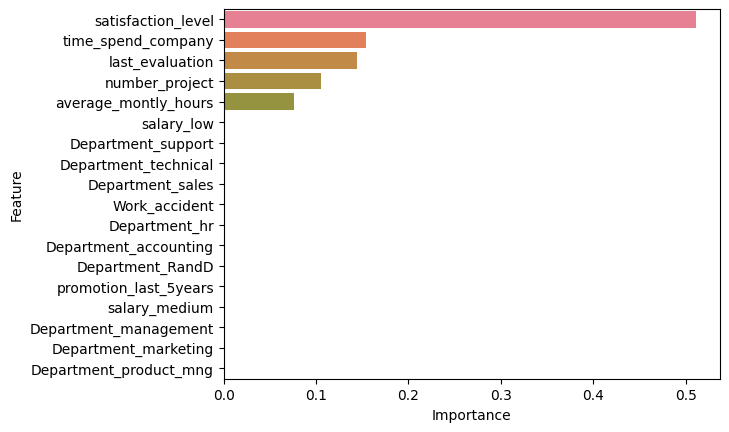

In [31]:
sns.barplot(data=df,x='Importance',y='Feature',hue='Feature')